# PHY588 Assignment 2

### 1. Metropolis MCMC
#### a)

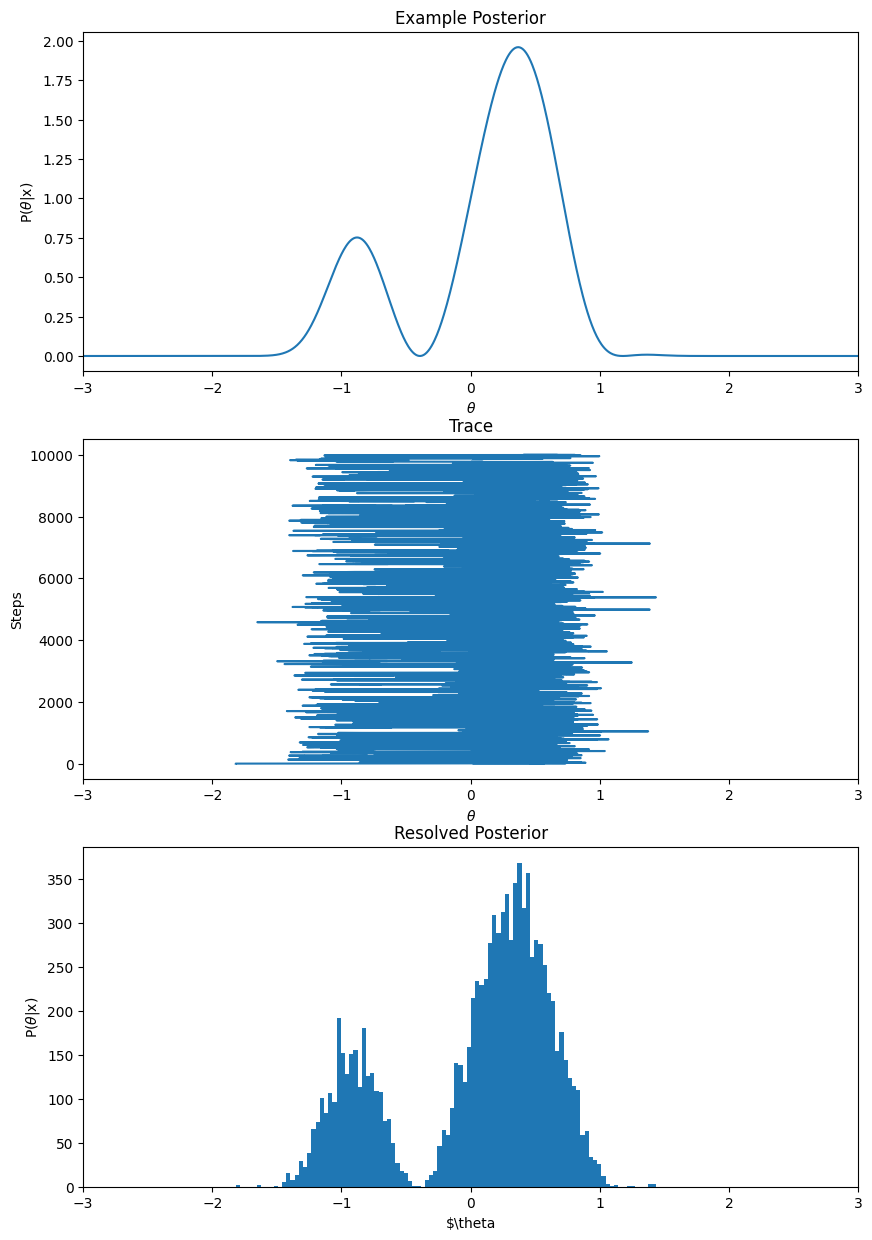

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import redback
from redback.simulate_transients import SimulateGenericTransient
from scipy.interpolate import interp1d
from bilby.core.prior import Uniform
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)    #redback creates issues with matplotlib, need to reset with this line

def MCMC(theta_initial, joint, sigma, steps=1000):
    theta_0 = theta_initial    # Starting point in parameter space
    trace = []
    for i in range(steps):      # Repeat algorithm N times
        theta_prime = np.random.normal(theta_0, sigma)  # Propose move from Gaussian Kernel
        P_theta_prime = joint(theta_prime)
        P_theta_0 = joint(theta_0)
        P_quotient = P_theta_prime/P_theta_0
        if P_quotient >= 1:     # Acceptence if P improves
            theta_next = theta_prime
        elif P_quotient < 1:    # If P does not improve...
            accept = np.random.rand()
            if accept <= P_quotient:    # Accept with probability P(theta') / P(theta_0)
                theta_next = theta_prime
            else:
                theta_next = theta_0    # Reject move
        theta_0 = theta_next        # Set next theta
        trace.append(theta_0)
    return np.array(trace)

N_steps = np.arange(10000)
test_prior = Uniform(-2, 2) #arbitrary starting point in random fxn for test
def test_joint(x):
    return (np.exp(-x**4))*(1+np.sin(4*x))

test_x = np.linspace(-3,3,1000)

theta_init = test_prior.sample()
test_trace = MCMC(theta_init, test_joint, sigma=0.5, steps=10000)

fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(10,15))
ax1.plot(test_x, test_joint(test_x))
ax1.set_title('Example Posterior')
ax1.set_xlim(-3,3)
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel(r'P($\theta$|x)')
ax2.plot(test_trace, N_steps)
ax2.set_title('Trace')
ax2.set_xlim(-3,3)
# ax2.set_ylim(9800,10000)
ax2.set_xlabel(r'$\theta$')
ax2.set_ylabel('Steps')
ax3.hist(test_trace, bins=100)
ax3.set_title('Resolved Posterior')
ax3.set_xlim(-3,3)
ax3.set_xlabel(r'$\theta')
ax3.set_ylabel(r'P($\theta$|x)')
plt.show()

#### b)
I will be using this algorithm to optimize the parameters for the least-squares fit I did in Question 1 of Assignment 1. I start by importing the necessary data, as done in Assignment 1. 

In [3]:
## Lists for the stretch and decline rate parameters. 
list_delta_m15 = []
list_x1 = []

## Producing 1000 SALT2 lightcurves with a range of x1 values and determining their decline rates
for i in range(1000):
    params = redback.priors.get_priors(model='salt2').sample()
    params['redshift'] = 0      ## To find the rest frame relationship
    times = np.linspace(0.2,70,100)   ## Days for the light curve
    bands = ['lsstg']
    model_kwargs = {'bands':bands, 'output_format':'magnitude'}

    ## Simulating the LCs
    sn_obs = SimulateGenericTransient(model='salt2', parameters=params,
                                    times=times, data_points=100, model_kwargs=model_kwargs,
                                    multiwavelength_transient=True, noise_term=0.0)

    ## Using Nearest Neighbours interpolation to approximate the decline rate
    mag_interp = interp1d(x=sn_obs.data['time'], y=sn_obs.data['output'], kind='nearest')
    time_interp = interp1d(x=sn_obs.data['output'], y=sn_obs.data['time'])

    peak_mag = mag_interp(params['peak_time'])
    decline_mag = mag_interp(params['peak_time'] + 15)

    delta_m15 = decline_mag - peak_mag

    list_delta_m15.append(delta_m15)
    list_x1.append(params['x1'])

delM15_values = np.array(list_delta_m15)
x1_values = np.array(list_x1)

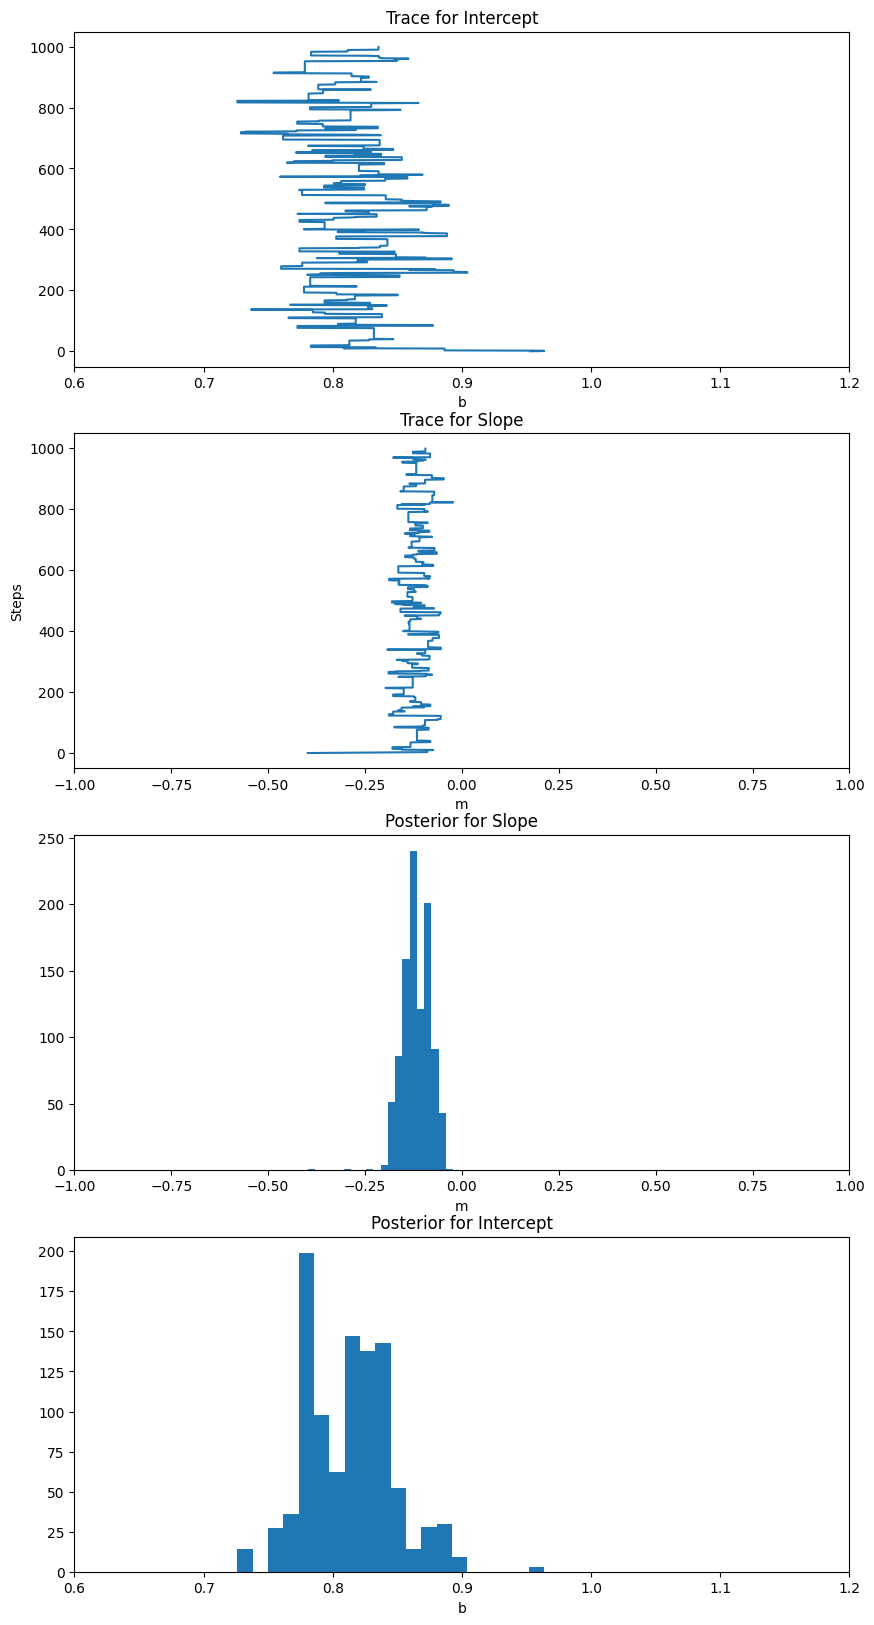

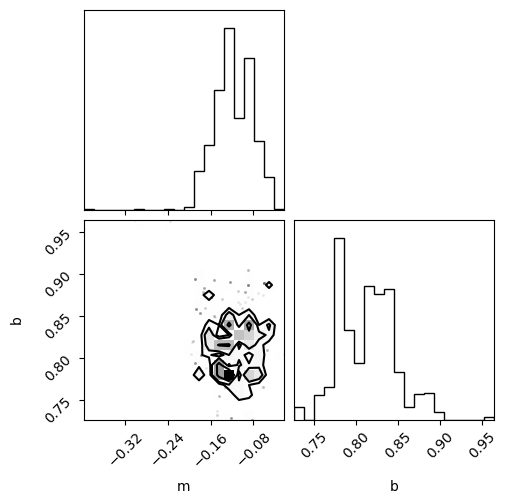

In [ ]:
import corner

def least_squares_likelihood(params):   # Likelihood for MCMC
    m, b = params
    residuals = delM15_values - (m*x1_values + b)
    return np.exp(-0.5*np.sum(residuals**2))

# Slope and intercept starting points from flat priors
slope_0 = np.random.rand()*2 -1     # from -1 to 1
intercept_0 = np.random.rand()*0.6 + 0.6    # from 0.6 to 1.2

params_init = [slope_0, intercept_0]
final_trace = MCMC(params_init, least_squares_likelihood, 0.1, 1000)

m_trace = final_trace[:,0]
b_trace = final_trace[:,1]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize=(10,20)) ## Visualize posterior


ax2.plot(m_trace, np.arange(1000))
ax2.set_xlim(-1,1)
ax2.set_title('Trace for Slope')
ax2.set_ylabel('Steps')
ax2.set_xlabel('m')

ax1.plot(b_trace, np.arange(1000))
ax1.set_xlim(0.6,1.2)
ax1.set_title('Trace for Intercept')
ax2.set_ylabel('Steps')
ax1.set_xlabel('b')

ax3.hist(m_trace, bins=20)
ax3.set_xlim(-1,1)
ax3.set_title('Posterior for Slope')
ax3.set_xlabel('m')

ax4.hist(b_trace, bins=20)
ax4.set_xlim(0.6,1.2)
ax4.set_title('Posterior for Intercept')
ax4.set_xlabel('b')

corner.corner(final_trace, labels=['m', 'b'], bins=20)

plt.show()

### 2. Hierarchical Bayesian Inference

In Homework 1, I proposed using Hierarchical Bayesian Inference to infer the intrinsic detectability fraction of transients, $f_k$, in a given redshift bin, $z_k$. This $f_k$ will be drawn from a beta distribution prior, to ensure it is kept between 0 and 1. The beta distribution will have a mean value, $\mu_k$, and variance, $\gamma$. $\mu_k$ will be determined via the following function:
$$
\mu_k = e^{-\alpha z_k}
$$
where $z_k$ will be the central redshift for a given redshift bin, and $\alpha$ will be the hyperparameter that determines the expected fall-off rate of the transient. $\alpha$ will, itself, be drawn from another beta distribution with hyperparameters $a=3$ and $b=7$, forming a loosely constrained hyperprior with a mean value of 0.3, approximated via detection curves plotted for my research. Therefore, my hierarchical model will seek to infer $\alpha$ (the decline rate of detectability as a function of redshift), as well as $\vec{f} = [f_1, f_2,...,f_k]$  (the intrinsic detectability fraction in a given redshift bin). My dataset, $\vec{y}$, contains ~10000 datapoints, each with a redshift and boolean detection parameter. Therefore, I seek to infer:
$$
P(\alpha, \vec{f} | \vec{y})
$$
Using Bayes' Rule, as seen in class, this posterior is proportional to the following expression:
$$
P(\alpha, \vec{f} | \vec{y}) \propto [\prod_{i}P(\vec{y_i}|\vec{f_{k_i}})\prod_{k}P(\vec{f_k}|\alpha)]P(\alpha)
$$
since each ith datapoint can belong to a different bin. 

Working in log space, the expression becomes:
$$
logP(\alpha, \vec{f} | \vec{y}) \propto logP(\alpha) + \sum_{i}logP(\vec{y_i}|\vec{f_{k_i}}) + \sum_{k}logP(\vec{f_k}|\alpha)
$$

where $logP(\alpha)$ is the hyperprior, $logP(\vec{y}|\vec{f_k})$ is the likelihood (Bernouli Distribution), and $logP(\vec{f_k}|\alpha)$ represents the beta distribution from which $\vec{f_k}$ is drawn, with mean value $\mu_k$. This beta distribution has hyperparameters $a$ and $b$, that must yield $\mu_k$ using the following beta function property:
$$
\mu_k = \frac{a}{a+b}
$$
To remove ambiguity, we will reparameterize the above expression to define the beta distribution as a function of $\mu_k$ and $\gamma$, as previously mentioned:
$$
\gamma = a + b
$$
$$
a = \mu_k \gamma
$$
$$
a = \gamma - b
$$
$$
b = \gamma(1-\mu_k)
$$

Rewriting the expression for the posterior with each distribution function yields the following:
$$
logP(\alpha, \vec{f} | \vec{y}) \propto log[\alpha^{a-1}(1-\alpha)^{b-1}] + \sum_{k}[log[\vec{f_{k}}^{x_k}(1-\vec{f_{k}})^{n_k - x_k}] + log[{f_k}^{\gamma\mu_k - 1}(1-{f_k})^{\gamma(1-\mu_k) - 1}]]
$$
where $x_k$ is the number of detections in each redshift bin, $z_k$.

Lastly, rewriting the above expression with the aforementioned values for $a$ and $b$, as well as replacing $\mu_k$ as a function of $\alpha$, yields the final expression for the log of the posterior.

$$
logP(\alpha, \vec{f} | \vec{y}) \propto log[\alpha^{2}(1-\alpha)^{6}] + \sum_{k}[log[\vec{f_{k}}^{x_k}(1-\vec{f_{k}})^{n_k - x_k}] + log[{f_k}^{\gamma{e^{-\alpha z}} - 1}(1-{f_k})^{\gamma(1-{e^{-\alpha z}}) - 1}]]
$$

In [ ]:
import emcee
import pandas as pd
from numpy.random import beta

df = pd.read_csv('TDE_SimData.csv')
# Binning redshift from dataframe
df = df[['redshift', 'Class']]
df = df[df['Class'] != 'Negative Flux Error']
df['Class'] = df['Class'].map({'Detected': 1, 'Undetected':0})

bins = np.linspace(0,3,13)
z_central = np.linspace(0,3,13) + 0.125 # Central z value in each bin
z_k = z_central[:12]
df['bins'] = np.digitize(df['redshift'], bins) - 1
n_k = df.groupby('bins').size()
x_k = df.groupby('bins')['Class'].sum()

binned_df = pd.DataFrame({'z_k': z_k, 'x_k': x_k, 'n_k': n_k}).reset_index(drop=True)
# print(binned_df)

# Hyperprior
def log_p_alpha(alpha):
    return np.log10((alpha**2)*(1-alpha)**6)

# Likelihood
def log_l_fk(xk, fk, nk):
    return np.sum(xk*np.log10(fk) + (nk-xk)*np.log10(1-fk))

# Prior for f_k
def log_p_fk(alpha, fk, zk):
    gamma = 10
    return np.sum((gamma*np.exp(-alpha*zk) - 1)*np.log10(fk) + (gamma*(1-np.exp(-alpha*zk)) - 1)*np.log10(1-fk))

# Posterior
def log_post(theta, zk, nk, xk):
    alpha = theta[0]
    fk = theta[1:]

    ## Fixing crash issue due to NaN
    if alpha <=0 or alpha >=1:
        return -np.inf
    if np.any(fk <= 0) or np.any(fk >= 1):
        return -np.inf

    log_p_a = log_p_alpha(alpha)
    log_l_f = log_l_fk(xk, fk, nk)
    log_p_f = log_p_fk(alpha, fk, zk)

    return log_p_a + log_l_f + log_p_f

n_dim = len(z_k) + 1 #f_k and alpha
n_walkers = 32

# Initial values for parameters
alpha_0 = 0.3
f_k_0 = x_k.values / n_k.values

# Starting positions for walkers, randomly dispered around initial values
position_0 = np.zeros((n_walkers, n_dim))
position_0[:,0] = alpha_0 + (1e-2*np.random.randn(n_walkers))
position_0[:,1:] = f_k_0 + (1e-2*np.random.randn(n_walkers, len(z_k)))

run_MCMC = emcee.EnsembleSampler(nwalkers=n_walkers, ndim=n_dim, log_prob_fn=log_post, args=(z_k, n_k.values, x_k.values))
run_MCMC.run_mcmc(position_0, 5000, progress=True)


100%|██████████| 5000/5000 [00:03<00:00, 1313.60it/s]


State([[0.24053174 0.74747622 0.63537319 0.62122655 0.54749046 0.56175906
  0.49671113 0.4530354  0.49622961 0.42223708 0.38909033 0.46482824
  0.40318831]
 [0.63868508 0.76752944 0.68112336 0.58200743 0.56644068 0.53987969
  0.49119202 0.44510731 0.45344385 0.41529657 0.39234465 0.41897448
  0.40655413]
 [0.59109344 0.76812485 0.66410267 0.63475123 0.50294254 0.51903595
  0.46901292 0.4730201  0.46461865 0.41104447 0.41525793 0.44461662
  0.42055478]
 [0.5246883  0.74382719 0.6386115  0.57538616 0.54777596 0.55492252
  0.50679576 0.46488068 0.48858428 0.39059658 0.41604119 0.3894167
  0.4237217 ]
 [0.02859865 0.74343997 0.65901429 0.62601777 0.5566267  0.5511636
  0.48050074 0.4655438  0.4362245  0.45477493 0.37707492 0.42387261
  0.3961255 ]
 [0.51307752 0.74800238 0.63865087 0.60440144 0.51767494 0.55424408
  0.54944914 0.43651611 0.50406461 0.39288545 0.36602128 0.46965556
  0.34126484]
 [0.52625894 0.76178988 0.68761116 0.64012137 0.55648741 0.58668014
  0.53569136 0.45374565 0.48

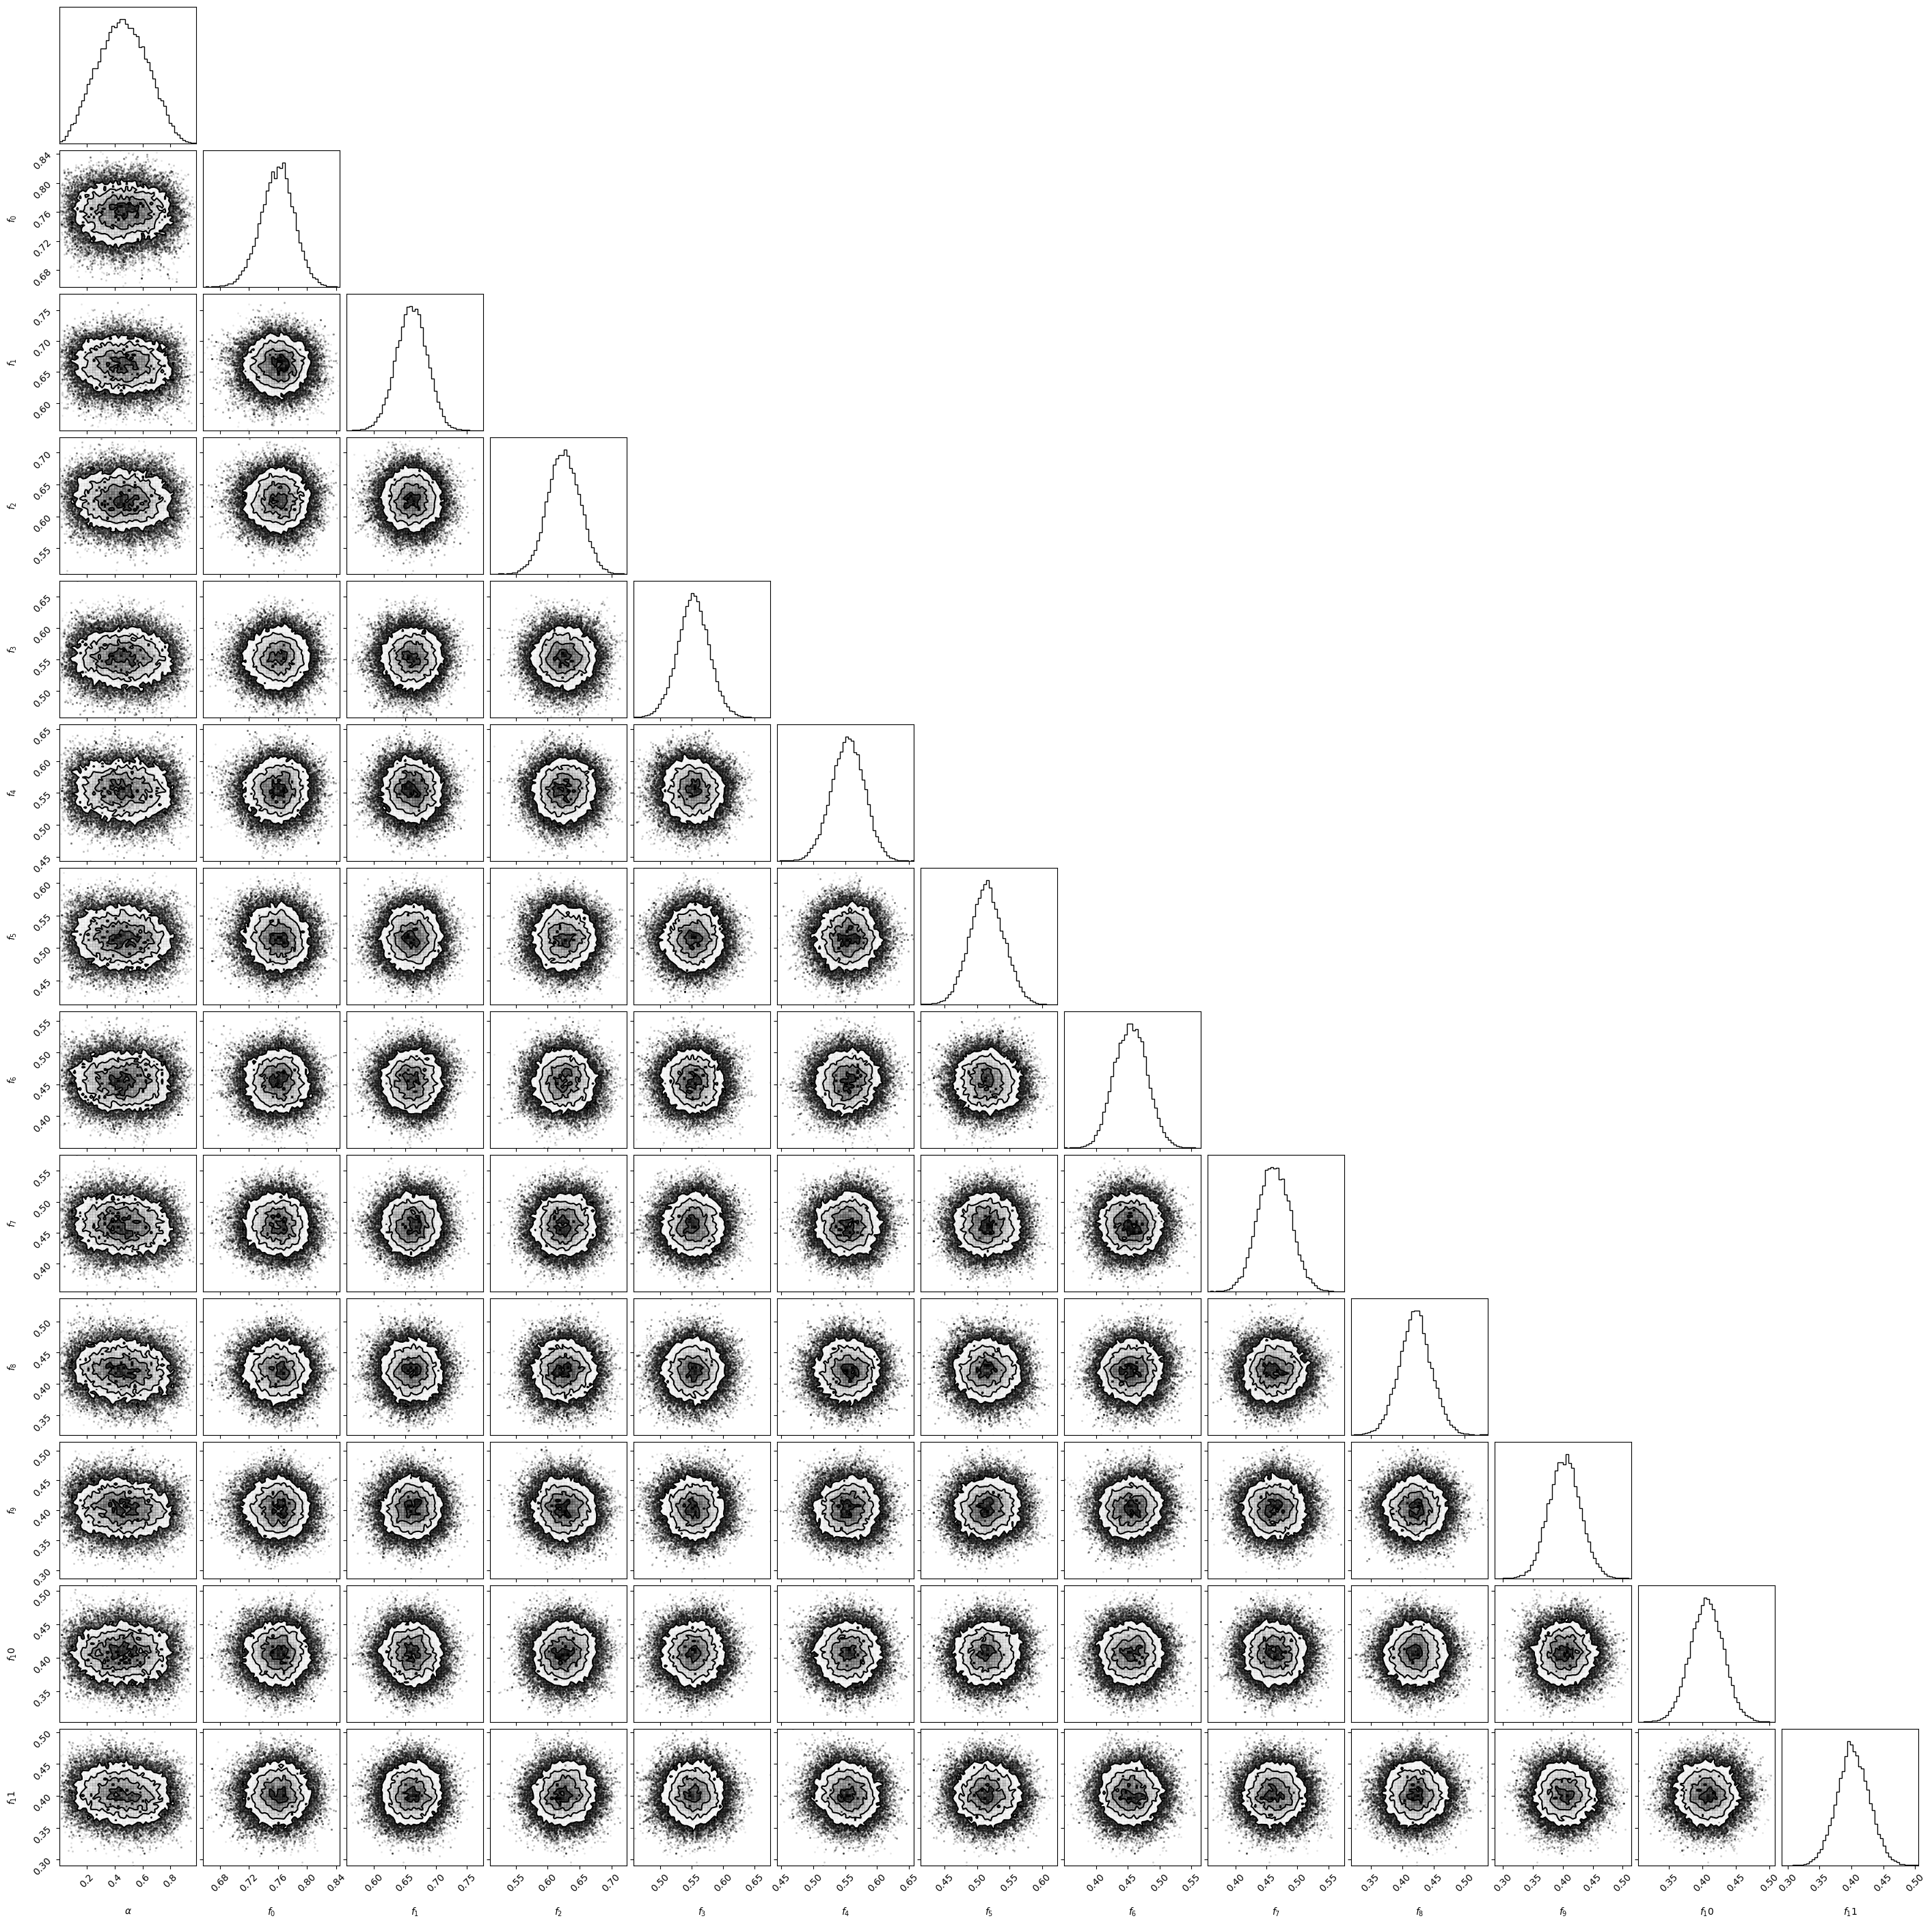

In [214]:
posteriors = run_MCMC.get_chain(discard=200, flat=True)

alpha_post = posteriors[:,0]
f_k_post = posteriors[:,1:]

labels = [rf'$\alpha$', rf'$f_0$', rf'$f_1$',rf'$f_2$',rf'$f_3$',rf'$f_4$',rf'$f_5$',rf'$f_6$',rf'$f_7$',rf'$f_8$',rf'$f_9$',rf'$f_{10}$',rf'$f_{11}$']
corner.corner(posteriors, labels=labels, bins=50)
plt.show()

### 3. Dimensionality Reduction
#### a) Performing PCA
I will use PCA on a set of normalized lightcurves $(M' = M - M_{peak})$ generated from the SALT2 SN Ia model. 

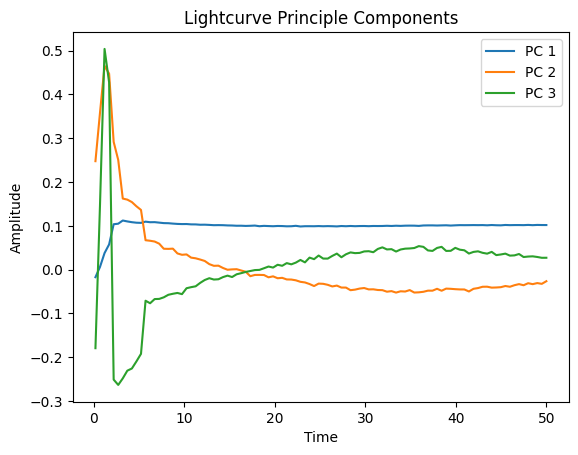

In [ ]:
from sklearn.decomposition import PCA
# Loading in data (lightcurves)
LCs = pd.read_csv('SALT2_LCs.csv')
LC_data = LCs.values

pca = PCA(n_components=10)
LC_pca = pca.fit_transform(LC_data)

# Same time grid the lightcurves were generated with
time = np.linspace(0.2,50,100)

for i in range(3):
    plt.plot(time, pca.components_[i], label=f'PC {i+1}')

plt.title('Lightcurve Principle Components')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

#### b) Scree Plot

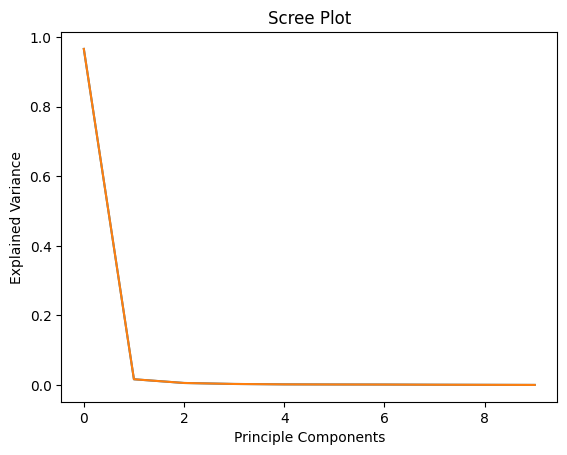

In [220]:
# Scree Plot

var = pca.explained_variance_ratio_
plt.plot(var)
plt.title('Scree Plot')
plt.xlabel('Principle Components')
plt.ylabel('Explained Variance')
plt.show()

The above scree plot shows that ~96% of the variance in my lightcurves can be represented by the first principle component. By the third principle component, most lightcurves should be able to be fully reconstructed. 

#### c) Data Reconstruction
I will reconstruct one of the lightcurves by summing the first few PCs.

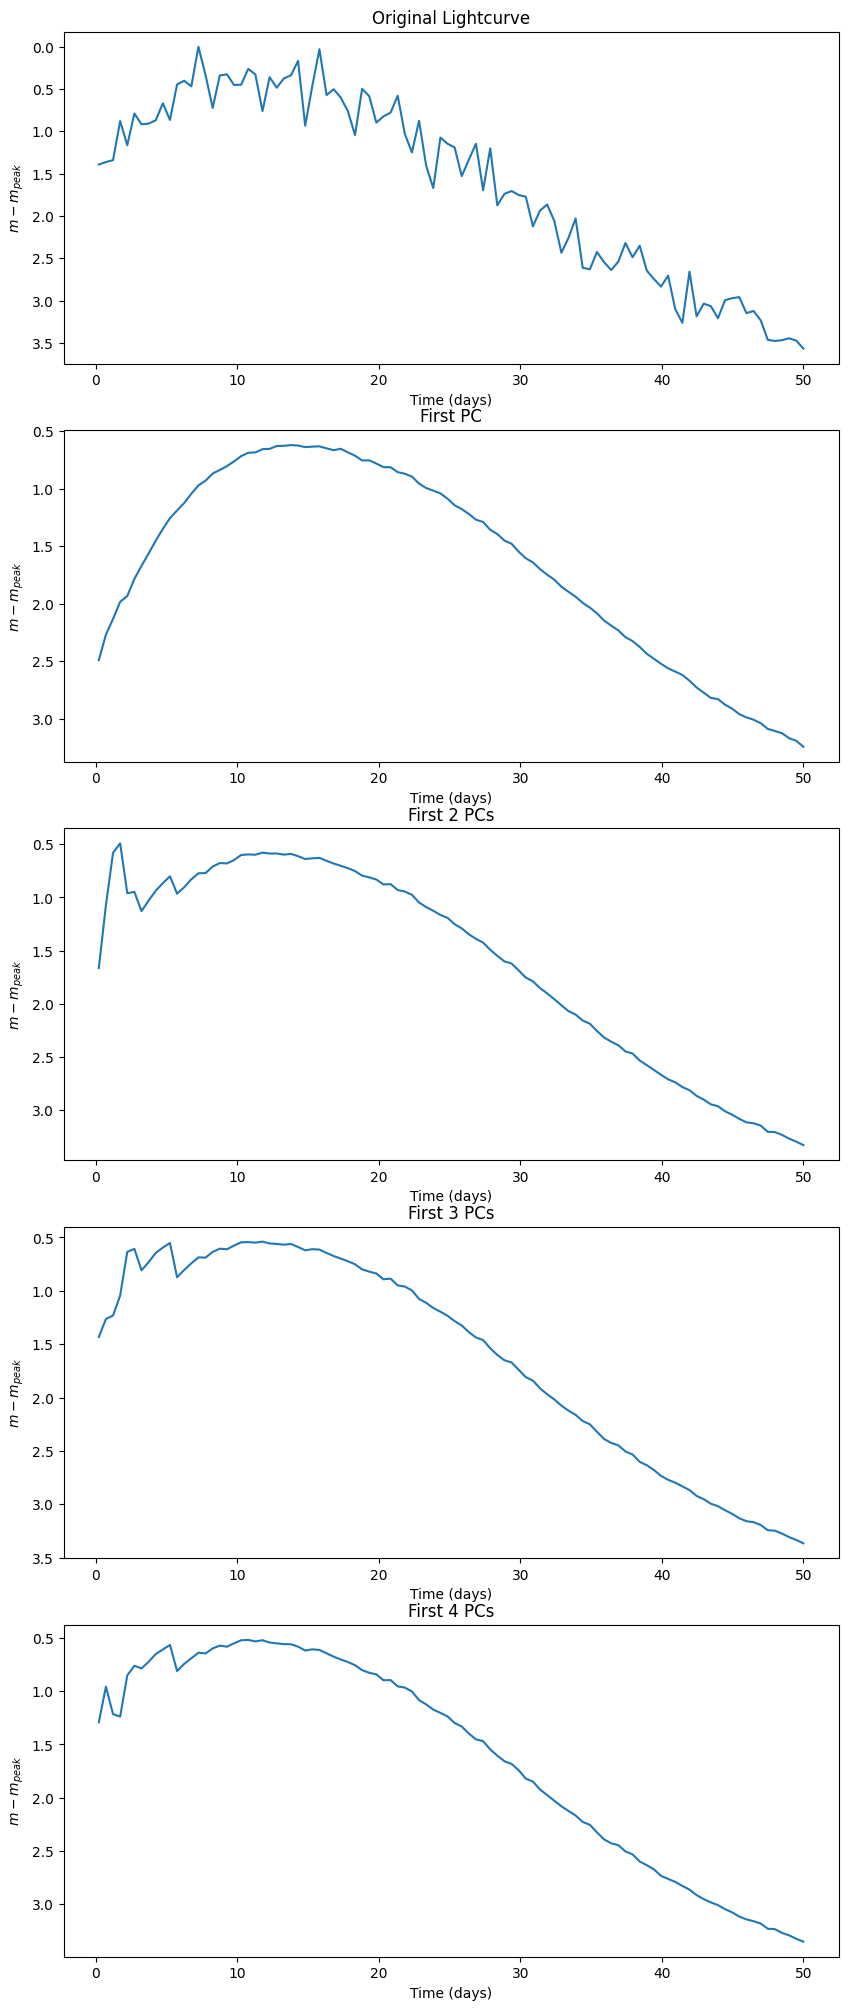

In [232]:
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, figsize=(10,25))

ax1.plot(time, LC_data[0])
ax1.invert_yaxis()
ax1.set_xlabel('Time (days)')
ax1.set_ylabel(r'$m-m_{peak}$')
ax1.set_title('Original Lightcurve')

ax2.plot(time, pca.mean_ + pca.components_[0]*LC_pca[0,0])
ax2.invert_yaxis()
ax2.set_xlabel('Time (days)')
ax2.set_ylabel(r'$m-m_{peak}$')
ax2.set_title('First PC')


ax3.plot(time, pca.mean_ + pca.components_[0]*LC_pca[0,0] + pca.components_[1]*LC_pca[0,1])
ax3.invert_yaxis()
ax3.set_xlabel('Time (days)')
ax3.set_ylabel(r'$m-m_{peak}$')
ax3.set_title('First 2 PCs')

ax4.plot(time, pca.mean_ + pca.components_[0]*LC_pca[0,0] + pca.components_[1]*LC_pca[0,1] + pca.components_[2]*LC_pca[0,2])
ax4.invert_yaxis()
ax4.set_xlabel('Time (days)')
ax4.set_ylabel(r'$m-m_{peak}$')
ax4.set_title('First 3 PCs')

ax5.plot(time, pca.mean_ + pca.components_[0]*LC_pca[0,0] + pca.components_[1]*LC_pca[0,1] + pca.components_[2]*LC_pca[0,2] + pca.components_[3]*LC_pca[0,3])
ax5.invert_yaxis()
ax5.set_xlabel('Time (days)')
ax5.set_ylabel(r'$m-m_{peak}$')
ax5.set_title('First 4 PCs')

plt.show()

The above plots show that the first PC on its own can reconstruct the shape of the original light curve. Additional PCs attempt to recreate the variability in the original lightcurve, though each PCs' improvement is negligible. 

### 4. Neural Networks
I will use a neural network to classify transients as detections or non-detections, similarly to how I used LDA in assignment 1. I will input the parameters used to generate each lightcurve, and output a binary classification.

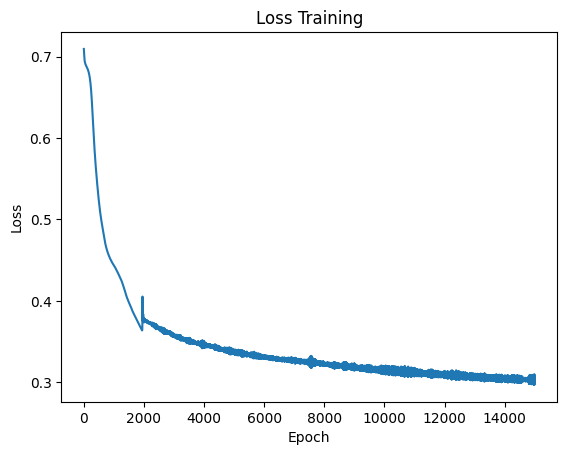

In [ ]:
import torch
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch import optim

# Loading in TDE Lightcurve Data
TDE_Data = pd.read_csv('TDE_SimData.csv')
fullSet = TDE_Data[TDE_Data['Class']!='Negative Flux Error']
X = fullSet.iloc[:,0:8]
Y = fullSet.iloc[:,8]

# Changing data type of classification
encoder = LabelEncoder()
encoder.fit(Y)
Y = encoder.transform(Y)

X = torch.tensor(X.values, dtype=torch.float64)
Y = torch.tensor(Y, dtype=torch.float32).reshape(-1,1)

X = (X-X.mean(dim=0)) / X.std(dim=0)    # Scaling data
X = X.float()       # Ensuring all data are floats and that they are scaled to avoid having large values for some of the parameters.

N = X.shape[0]
ind = torch.randperm(N)

training_size = int(0.6*N)      # Breaking full dataset into 60% training and 40% test
train_ind = ind[:training_size]
test_ind = ind[training_size:]
X_train = X[train_ind]
Y_train = Y[train_ind]
X_test = X[test_ind]
Y_test = Y[test_ind]

class TestNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(8,16)
        self.act1 = nn.ReLU()
        self.layer2 = nn.Linear(16,8)
        self.act2 = nn.ReLU()
        self.layer3 = nn.Linear(8,4)
        self.act3 = nn.ReLU()
        self.layer4 = nn.Linear(4,2)
        self.act4 = nn.ReLU()
        self.output = nn.Linear(2,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act1(self.layer1(x))
        x = self.act2(self.layer2(x))
        x = self.act3(self.layer3(x))
        x = self.act4(self.layer4(x))
        x = self.sigmoid(self.output(x))
        return x

model = TestNN()
loss_fxn = nn.BCELoss() # Binary cross-entropy loss function
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.88)    # Stochastic Gradient Descent

# Training Loop Here
loss_vals = []

for epoch in range(15000):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = loss_fxn(outputs, Y_train)
    loss_vals.append(loss.item())
    loss.backward() # Backpropagation
    optimizer.step()

# Plotting loss function
plt.plot(loss_vals)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Training')
plt.show()

In [133]:
with torch.no_grad():
    outputs = model(X_test) # Outputs from test set
    predictions = (outputs > 0.5).float()
    accuracy = (predictions == Y_test).float().mean()

print(f'Accuracy of Neural Network: {accuracy}')

Accuracy of Neural Network: 0.8267499804496765


After adjusting the architecture of this neural network, I was able to obtain an accuracy of ~83%. This is a great improvement from the accuracy of using LDA in the previous assignment (~60%), though 83% still feels too low to reliably attempt to use this network to predict whether or not a given TDE will be detected based on its input parameters. 